In [1]:
from pathlib import Path
import numpy as np
import cv2
from skimage.feature import hog
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

ROOT = Path(".")
DATA = ROOT / "data"
TRAIN_DIR = DATA / "train"
TEST_DIR  = DATA / "test"
OUT       = ROOT / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
IMG_SIZE = 128
SEED     = 42


In [2]:
def is_genuine_dir(name: str) -> bool:
    """Return True for folders that are genuine (not ending with '_forg')."""
    return not name.lower().endswith("_forg")

def list_genuine(root: Path):
    """
    Collect image paths and person IDs from genuine-only folders.
    Returns paths and person labels.
    """
    paths, pids = [], []
    for d in sorted([x for x in root.iterdir() if x.is_dir() and is_genuine_dir(x.name)]):
        pid = d.name
        for f in d.rglob("*"):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(f)
                pids.append(pid)
    return paths, pids

tr_paths, tr_pids = list_genuine(TRAIN_DIR)
te_paths, te_pids = list_genuine(TEST_DIR)

all_pids = sorted(set(tr_pids))
pid2idx  = {p: i for i, p in enumerate(all_pids)}

X_tr_all = tr_paths
y_tr_all = [pid2idx[p] for p in tr_pids]

X_te_all = [p for p, pid in zip(te_paths, te_pids) if pid in pid2idx]
y_te_all = [pid2idx[pid] for pid in te_pids if pid in pid2idx]


Remove unreadable images + Split

In [3]:
def keep_readable(paths, labels):
    """Remove unreadable images (corrupt files)."""
    kp, kl = [], []
    for p, y in zip(paths, labels):
        try:
            _ = Image.open(p).convert("L")
            kp.append(p); kl.append(y)
        except Exception:
            pass
    return kp, kl

X_tr_all, y_tr_all = keep_readable(X_tr_all, y_tr_all)
X_te_all, y_te_all = keep_readable(X_te_all, y_te_all)

idx = np.arange(len(X_tr_all))
tr_idx, va_idx = train_test_split(idx, test_size=0.15, random_state=SEED, stratify=y_tr_all)

X_tr = [X_tr_all[i] for i in tr_idx]; y_tr = [y_tr_all[i] for i in tr_idx]
X_va = [X_tr_all[i] for i in va_idx];  y_va = [y_tr_all[i] for i in va_idx]
num_classes = len(all_pids)


HOG feature extraction

In [4]:
def compute_hog_features(paths, image_size=128):
    """
    Compute HOG features for each image.
    Returns feature array and valid indices.
    """
    feats, good = [], []
    for i, p in enumerate(paths):
        im = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if im is None:
            continue
        im = cv2.resize(im, (image_size, image_size))
        f = hog(
            im,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            transform_sqrt=True,
            feature_vector=True
        )
        feats.append(f); good.append(i)
    return np.asarray(feats), good


Build train/val/test feature matrices

In [6]:
H_tr, gi_tr = compute_hog_features(X_tr, image_size=IMG_SIZE)
y_tr2 = np.asarray([y_tr[i] for i in gi_tr], dtype=int)

H_va, gi_va = compute_hog_features(X_va, image_size=IMG_SIZE)
y_va2 = np.asarray([y_va[i] for i in gi_va], dtype=int)

H_te, gi_te = compute_hog_features(X_te_all, image_size=IMG_SIZE)
y_te2 = np.asarray([y_te_all[i] for i in gi_te], dtype=int)


Train LinearSVM and validate

In [7]:
def train_hog_svm(X_tr, y_tr, X_va, y_va):
    """
    Train LinearSVM on HOG descriptors and evaluate validation metrics.
    """
    clf = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("svm", LinearSVC(C=1.0, max_iter=10000))
    ])
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_va)
    acc = accuracy_score(y_va, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_va, pred, average="macro", zero_division=0)
    return clf, {"val_acc": acc, "val_prec_macro": prec, "val_rec_macro": rec, "val_f1_macro": f1}

clf, val_metrics = train_hog_svm(H_tr, y_tr2, H_va, y_va2)
print(val_metrics)


{'val_acc': 0.9552238805970149, 'val_prec_macro': np.float64(0.97265625), 'val_rec_macro': np.float64(0.953125), 'val_f1_macro': np.float64(0.9519345238095238)}


Test evaluation and Confusion Matrix


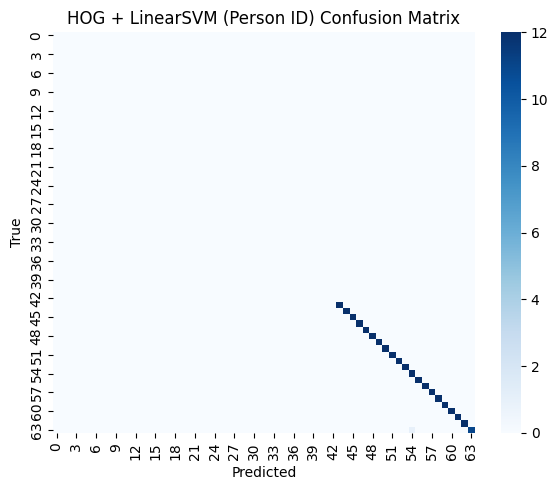

              precision    recall  f1-score   support

          43     1.0000    1.0000    1.0000        12
          44     1.0000    1.0000    1.0000        12
          45     1.0000    1.0000    1.0000        12
          46     1.0000    1.0000    1.0000        12
          47     1.0000    1.0000    1.0000        12
          48     1.0000    1.0000    1.0000        12
          49     1.0000    1.0000    1.0000        12
          50     1.0000    1.0000    1.0000        12
          51     1.0000    1.0000    1.0000        12
          52     1.0000    1.0000    1.0000        12
          53     1.0000    1.0000    1.0000        12
          54     0.9231    1.0000    0.9600        12
          55     1.0000    1.0000    1.0000        12
          56     1.0000    1.0000    1.0000        12
          57     1.0000    1.0000    1.0000        12
          58     1.0000    1.0000    1.0000        12
          59     1.0000    1.0000    1.0000        12
          60     1.0000    

In [8]:
def evaluate_and_save(clf, X_te, y_te, out_dir: Path, num_classes: int):
    """
    Evaluate classifier on test features and save confusion matrix + report.
    """
    pred = clf.predict(X_te)
    report_str = classification_report(y_te, pred, digits=4)
    cm = confusion_matrix(y_te, pred, labels=list(range(num_classes)))

    with open(out_dir / "hog_svm_classification_report.txt", "w") as f:
        f.write(report_str)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title("HOG + LinearSVM (Person ID) Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(out_dir / "hog_id_confusion.png", dpi=150)
    plt.show()

    return report_str, cm

report_str, cm = evaluate_and_save(clf, H_te, y_te2, OUT, num_classes)
print(report_str)


Train vs Test Accuracy Plot

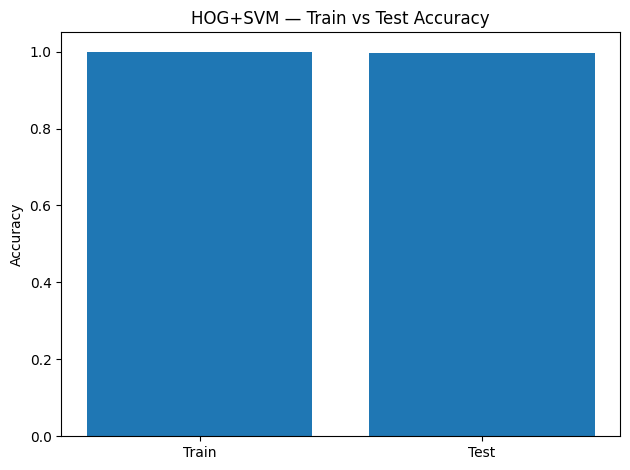

{'hog_train_acc': 1.0, 'hog_test_acc': 0.996031746031746}


In [9]:
from sklearn.metrics import accuracy_score

hog_train_pred = clf.predict(H_tr)
hog_train_acc  = accuracy_score(y_tr2, hog_train_pred)
hog_test_pred  = clf.predict(H_te)
hog_test_acc   = accuracy_score(y_te2, hog_test_pred)

plt.figure()
plt.bar(["Train", "Test"], [hog_train_acc, hog_test_acc])
plt.ylabel("Accuracy")
plt.title("HOG+SVM — Train vs Test Accuracy")
plt.tight_layout()
plt.savefig(OUT / "hog_train_test_accuracy.png", dpi=150)
plt.show()

print({"hog_train_acc": hog_train_acc, "hog_test_acc": hog_test_acc})


Both models performed extremely well on the signature identification task. The CNN reached about 98% accuracy, showing that it learned to recognize each person’s writing style effectively. The HOG + SVM approach performed even better on this clean dataset, achieving around 99.6% accuracy and almost perfect precision and recall. This suggests that for neat, high-contrast signature images, simple gradient-based features can work surprisingly well. However, a CNN would likely handle more complex or noisy data better, because it learns its own features automatically instead of relying on manually designed ones. Overall, both methods were highly accurate, with HOG + SVM slightly ahead on this dataset, but CNN offering more flexibility for real-world use.